# Load Packages 

In [2]:
# Core
import os
import sys

import anndata as ad
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

from pandarallel import pandarallel  # For making applying of a function faster
from sklearn.model_selection import GroupShuffleSplit, GroupKFold # data splitting and 5-fold cross-validation


pandarallel.initialize(progress_bar=True)

# Show all columns
pd.set_option("display.max_columns", None)
# Disable internal RDKit logs

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [3]:
sys.path.insert(0, "/Users/ani/Thesis/prnet_eval/data_preprocessing/scripts")

# scripts
from preprocessing.scripts.data_loading import load_metadata_txt, LINCSDataLoader
from preprocessing.scripts.inspect_fingerprints import get_fingerprint
from preprocessing.scripts.data_preprocessing import add_fingerprints, adapt_cols_to_prnet, del_insufficient_comp, pair_observations, del_false_duplicate_fp
from preprocessing.scripts.data_splitting import split_folds
from models.simple_baselines import control_baseline, mean_baseline, compute_technical_duplicate, plot_performance

In [4]:
# Utils
from pathlib import Path

# For gctx
from cmapPy.pandasGEXpress.parse import parse

# RDKit stuff
from rdkit import RDLogger

# Calculations

RDLogger.DisableLog("rdApp.*")

In [5]:
import warnings
from warnings import simplefilter

# Suppress specific FutureWarning from cmapPy/pandas interaction
warnings.filterwarnings("ignore", category=FutureWarning, module="cmapPy")
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

# Load Metadata

In [40]:
METADATA_EDITED_FOLDER = Path("./Metadata_edited/")
if not os.path.exists(METADATA_EDITED_FOLDER):
    os.mkdir(METADATA_EDITED_FOLDER)

In [ ]:
merged_LINCS_metadata_dir = Path("/Users/ani/Thesis/prnet_eval/dataset/metadata/LINCS")
save_dir_analysis_merged = merged_LINCS_metadata_dir / "Analysis"

In [42]:
comp_info_merged = load_metadata_txt(merged_LINCS_metadata_dir / "compoundinfo_beta.txt")
gene_info_merged = load_metadata_txt(merged_LINCS_metadata_dir / "geneinfo_beta.txt")
inst_info_merged = load_metadata_txt(merged_LINCS_metadata_dir / "instinfo_beta.txt")

# Data Cleaning (Metadata-Level)

##### 1. Add fingerprints to metadata and delete rows without canonical_smiles and fingerprint_smiles


If changes to parallelization of add_fingerprints has been made, rerun here to check if it still works (build new Metadata edited)

In [43]:
comp_metadata_path =  METADATA_EDITED_FOLDER / "compounds_info_fingerprints.parquet"

if os.path.isfile(comp_metadata_path):
    # Read Parquet instead of CSV
    comp_info_merged = pd.read_parquet(comp_metadata_path)
else:
    comp_info_merged = add_fingerprints(comp_metadata=comp_info_merged, verbose=True)

    # Save to Parquet
    comp_info_merged.to_parquet(comp_metadata_path, index=False)



In [ ]:
comp_info_merged = del_false_duplicate_fp(comp_metadata=comp_info_merged, verbose=True)


=== Drop Reason Breakdown (By Rows Affected) ===
fingerprint_smiles
Stereoisomers (R/S conflict)                                                                                                         19714
Defined vs Undefined Stereo                                                                                                            754
Defined vs Undefined Stereo, Stereoisomers (R/S conflict)                                                                              609
Compositional Isomer (Different Formula), Stereoisomers (R/S conflict)                                                                 516
Bioisosteres (Same Skeleton), Compositional Isomer (Different Formula), Stereoisomers (R/S conflict)                                   357
Bioisosteres (Same Skeleton), Compositional Isomer (Different Formula)                                                                 300
Bioisosteres (Same Skeleton), Structural Isomers (Positional)                                    

##### 2. Add and modify attributes for PRnet

In [45]:
inst_info_merged = adapt_cols_to_prnet(inst_metadata=inst_info_merged)

##### 3. Delete insufficient compound condition


In [46]:
inst_info_merged = del_insufficient_comp(inst_metadata=inst_info_merged, verbose=True)

741614 number of observation were insufficient and removed.


##### 4. Pair perturbed and unperturbed observations and delete unpaired ones

In [47]:
inst_info_merged = pair_observations(inst_metadata=inst_info_merged, verbose=True)

0 number of observations left unpaired and removed.


##### 5. Subset metadata into control and compound 

In [48]:
controls = ["ctl_x", "ctl_vehicle", "ctl_untrt", "ctl_vector"] 

inst_info_merged_control = inst_info_merged[
    inst_info_merged["pert_type"].isin(controls)
]

inst_info_merged_comp = inst_info_merged[inst_info_merged["pert_type"] == "trt_cp"]

In [49]:
inst_info_merged_control

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,sample_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index
1,b10,,1.0,uL,1 uL,96.0,96 h,h,U2OS,TRCN0000072237,TAK004_U2OS_96H_X2_B10_DUO52HI53LO,D10,TAK004_U2OS_96H_X1,D10,67,18,5.7,14.98,67,TRCN0000072237,TAK004_U2OS_96H_X2_B10_DUO52HI53LO:D10,ctl_vector,U2OS,0,4.73906,1462,,inv_level_10,TAK,LACZ,TRCN0000072237,U2OS_TRCN0000072237,U2OS_TRCN0000072237_1.0,1,TAK004_U2OS_96H_X2_B10_DUO52HI53LO:D10
8,b11,,20.0,uL,20 uL,120.0,120 h,h,VCAP,TRCN0000072261,ERG013_VCAP_120H_X1_B11,A12,ERG013_VCAP_120H_X1,A12,108,14,5.9,22.92,70,TRCN0000072261,ERG013_VCAP_120H_X1_B11:A12,ctl_vector,VCAP,0,3.3136,1511,,"inv_level_10,qc_iqr,dyn_range",ERG,LUCIFERASE,TRCN0000072261,VCAP_TRCN0000072261,VCAP_TRCN0000072261_20.0,1,ERG013_VCAP_120H_X1_B11:A12
9,b12,,150.0,ng,150 ng,48.0,48 h,h,HEK293T,GFP,HSF043_HEK293T_48H_X1_B12,O04,HSF043_HEK293T_48H_X1,O04,91,15,6.5,11.23,63,GFP,HSF043_HEK293T_48H_X1_B12:O04,ctl_vector,HEK293T,1,6.44316,3344,,None,HSF,GFP,GFP,HEK293T_GFP,HEK293T_GFP_150.0,1,HSF043_HEK293T_48H_X1_B12:O04
13,b11,,20.0,uL,20 uL,72.0,72 h,h,VCAP,TRCN0000072261,ERG013_VCAP_72H_X1_B11,K24,ERG013_VCAP_72H_X1,K24,36,20,7.3,12.11,67,TRCN0000072261,ERG013_VCAP_72H_X1_B11:K24,ctl_vector,VCAP,0,4.13253,2401,,"count_mean,dyn_range",ERG,LUCIFERASE,TRCN0000072261,VCAP_TRCN0000072261,VCAP_TRCN0000072261_20.0,1,ERG013_VCAP_120H_X1_B11:A12
27,b12,,150.0,ng,150 ng,48.0,48 h,h,HEK293T,GFP,HSF039_HEK293T_48H_X1_B12,O01,HSF039_HEK293T_48H_X1,O01,74,17,6.6,8.72,58,GFP,HSF039_HEK293T_48H_X1_B12:O01,ctl_vector,HEK293T,1,20.3247,3130,,None,HSF,GFP,GFP,HEK293T_GFP,HEK293T_GFP_150.0,1,HSF043_HEK293T_48H_X1_B12:O04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469521,f2b4,,NaN,None,None,24.0,24 h,h,MCF7,DMSO,DOS033_MCF7_24H_X1_F2B4_DUO52HI53LO,E17,DOS033_MCF7_24H_X1,E17,79,29,7.8,12.27,68,DMSO,DOS033_MCF7_24H_X1_F2B4_DUO52HI53LO:E17,ctl_vehicle,MCF7,0,6.14767,1915,,count_cv,DOS,DMSO,DMSO,MCF7_DMSO,MCF7_DMSO_nan,1,PCLB001_MCF7_24H_X3.A2_B11_DUO52HI53LO:C18
469523,f2b4,,NaN,None,None,24.0,24 h,h,PC3,DMSO,DOS034_PC3_24H_X3_F2B4_DUO52HI53LO,E17,DOS034_PC3_24H_X3,E17,91,29,7.3,5.07,39,DMSO,DOS034_PC3_24H_X3_F2B4_DUO52HI53LO:E17,ctl_vehicle,PC3,0,8.58678,2078,,"count_cv,qc_iqr,qc_slope",DOS,DMSO,DMSO,PC3_DMSO,PC3_DMSO_nan,1,ERG013_PC3_96H_X2_B11:E18
469526,f2b4,,NaN,None,None,96.0,96 h,h,HCC515,CMAP-000,KDC010_HCC515_96H_X1_F2B4_DUO52HI53LO,D23,KDC010_HCC515_96H_X1,D23,79,28,7.5,13.01,68,CMAP-000,KDC010_HCC515_96H_X1_F2B4_DUO52HI53LO:D23,ctl_untrt,HCC515,0,7.5125,1502.5,,"count_cv,inv_level_10",KDC,UnTrt,CMAP-000,HCC515_CMAP-000,HCC515_CMAP-000_nan,1,DER001_HCC515_96H_X1.A2_B11_DUO52HI53LO:N01
469527,f2b5,,NaN,None,None,24.0,24 h,h,MDAMB231,DMSO,LJP002_MDAMB231_24H_X1_F2B5_DUO52HI53LO,D02,LJP002_MDAMB231_24H_X1,D02,108,15,8.1,12.11,66,DMSO,LJP002_MDAMB231_24H_X1_F2B5_DUO52HI53LO:D02,ctl_vehicle,MDAMB231,1,8.5669,2433,,None,LJP,DMSO,DMSO,MDAMB231_DMSO,MDAMB231_DMSO_nan,1,LJP001_MDAMB231_24H_X2_B2_DUO52HI53LO:H07


In [50]:
inst_info_merged_comp

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,sample_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index
5,f1b10,0.002,0.001500,uM,0.002 uM,6.0,6 h,h,A549,BRD-A61304759,HOG001_A549_6H_X4_F1B10,P11,HOG001_A549_6H_X4,P11,65,20,9.8,9.95,62,BRD-A61304759,HOG001_A549_6H_X4_F1B10:P11,trt_cp,A549,1,12.4715,2301,,None,HOG,tanespimycin,BRD-A61304759,A549_BRD-A61304759,A549_BRD-A61304759_0.0015,0,TA.KD010_A549_96H_X2_B16:K19
11,f1b10,0.02,0.015200,uM,0.02 uM,6.0,6 h,h,A549,BRD-K18190982,HOG002_A549_6H_X1_F1B10,G09,HOG002_A549_6H_X1,G09,46,21,8.6,10.63,64,BRD-K18190982,HOG002_A549_6H_X1_F1B10:G09,trt_cp,A549,1,8.83029,4110.5,,None,HOG,COT-10b,BRD-K18190982,A549_BRD-K18190982,A549_BRD-K18190982_0.0152,0,TA.KD010_A549_96H_X2_B16:K19
12,f1b10,0.002,0.001500,uM,0.002 uM,24.0,24 h,h,A549,BRD-A85860691,HOG001_A549_24H_X1_F1B10,J22,HOG001_A549_24H_X1,J22,71,18,7.7,9.74,59,BRD-A85860691,HOG001_A549_24H_X1_F1B10:J22,trt_cp,A549,1,11.5843,3023.5,,None,HOG,chaetocin,BRD-A85860691,A549_BRD-A85860691,A549_BRD-A85860691_0.0015,0,TA.KD010_A549_96H_X2_B16:K19
17,b10,0.002,0.001500,uM,0.002 uM,24.0,24 h,h,MCF7,BRD-K05649647,HOG002_MCF7_24H_X3_B10,O11,HOG002_MCF7_24H_X3,O11,60,18,6.1,15.2,67,BRD-K05649647,HOG002_MCF7_24H_X3_B10:O11,trt_cp,MCF7,0,3.01029,3802,,"qc_iqr,dyn_range",HOG,BRD-K05649647,BRD-K05649647,MCF7_BRD-K05649647,MCF7_BRD-K05649647_0.0015,0,PCLB001_MCF7_24H_X3.A2_B11_DUO52HI53LO:C18
21,b10,0.05,0.045700,uM,0.05 uM,24.0,24 h,h,MCF7,BRD-K12762134,HOG002_MCF7_24H_X3_B10,F19,HOG002_MCF7_24H_X3,F19,66,18,6.4,11.44,66,BRD-K12762134,HOG002_MCF7_24H_X3_B10:F19,trt_cp,MCF7,0,4.63017,4482,,dyn_range,HOG,XAV-939,BRD-K12762134,MCF7_BRD-K12762134,MCF7_BRD-K12762134_0.0457,0,PCLB001_MCF7_24H_X3.A2_B11_DUO52HI53LO:C18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190439,b39,0.125,0.156250,uM,0.125 uM,3.0,3 h,h,TMD8,BRD-K61567297,EMU001_TMD8_3H_X1_B39,A22,EMU001_TMD8_3H_X1,A22,83,15,5,18.43,55,BRD-K61567297,EMU001_TMD8_3H_X1_B39:A22,trt_cp,TMD8,0,17.1212,6215,,qc_iqr,EMU,resatorvid,BRD-K61567297,TMD8_BRD-K61567297,TMD8_BRD-K61567297_0.15625,0,AICHI002_TMD8_4H_X3_B32:N23
1190440,b39,0.125,0.156250,uM,0.125 uM,4.0,4 h,h,HBL1,BRD-K30520487,AICHI002_HBL1_4H_X2_B39,E16,AICHI002_HBL1_4H_X2,E16,78,15,4.8,26.31,57,BRD-K30520487,AICHI002_HBL1_4H_X2_B39:E16,trt_cp,HBL1,0,15.1448,3347,,"qc_f_logp,qc_iqr",AICHI,BRD-K30520487,BRD-K30520487,HBL1_BRD-K30520487,HBL1_BRD-K30520487_0.15625,0,AICHI001_HBL1_24H_X3_B32:L20
1190441,b39,0.125,0.156221,uM,0.125 uM,4.0,4 h,h,THP1,BRD-A79768653,AICHI002_THP1_4H_X3_B39,C22,AICHI002_THP1_4H_X3,C22,94,15,5.2,14.7,56,BRD-A79768653,AICHI002_THP1_4H_X3_B39:C22,trt_cp,THP1,1,5.82844,5164,,None,AICHI,sirolimus,BRD-A79768653,THP1_BRD-A79768653,THP1_BRD-A79768653_0.156221,0,KMS002_THP1_24H_X3_B5_DUO52HI53LO:D24
1190442,f1b3,0.125,0.156250,uM,0.125 uM,24.0,24 h,h,MCF7,BRD-K64606589,HDAC001_MCF7_24H_X1_F1B3_DUO52HI53LO,H10,HDAC001_MCF7_24H_X1,H10,103,16,8.6,13.17,68,BRD-K64606589,HDAC001_MCF7_24H_X1_F1B3_DUO52HI53LO:H10,trt_cp,MCF7,1,5.14642,3304,,None,HDAC,apicidin,BRD-K64606589,MCF7_BRD-K64606589,MCF7_BRD-K64606589_0.15625,0,PCLB001_MCF7_24H_X3.A2_B11_DUO52HI53LO:C18


# Loading GE

##### 1. Save paths

In [51]:
merged_LINCS_dataset_dir = Path("/Users/ani/Thesis/prnet_eval/dataset/data/LINCS")

In [52]:
save_dir_analysis = merged_LINCS_dataset_dir / "Analysis"

merged_LINCS_dataset_lvl3_trt_ctl_path = (
    merged_LINCS_dataset_dir / "level3_beta_ctl_n188708x12328.gctx"
)

merged_LINCS_dataset_lvl3_trt_cp_path = (
    merged_LINCS_dataset_dir / "level3_beta_trt_cp_n1805898x12328.gctx"
)

##### 2. Load the control and test (landmark) data 

In [53]:
# Load compound data 
dataloader_cp = LINCSDataLoader(
    gctx_path=merged_LINCS_dataset_lvl3_trt_cp_path,
    inst_info=inst_info_merged_comp,
    gene_info=gene_info_merged,
    gene_marker="landmark",  # used for testing
    comp_identifier="pert_id",  
    cell_identifier="cell_type",
    instance_identifier="sample_id",
)


Subsetting genes using feature_space: landmark
Initializing metadata...


In [54]:
# Load control data 
control = ["ctl_x", "ctl_vehicle", "ctl_untrt", "ctl_vector"] 
gene_info_merged["gene_id"] = gene_info_merged["gene_id"].astype(str)

dataloader_ctl = LINCSDataLoader(
    gctx_path=merged_LINCS_dataset_lvl3_trt_ctl_path,
    inst_info=inst_info_merged_control,
    gene_info=gene_info_merged,
    gene_marker="landmark",  # used as reference to perturbed landmark
    comp_identifier="pert_id",
    cell_identifier="cell_type",
    instance_identifier="sample_id",
    pert_types = control,  # set to "trt_cp" by default
)


Subsetting genes using feature_space: landmark
Initializing metadata...


##### 3. Set filters to create anndata objects (if needed)

In [55]:
# Assuming dataloader is your instantiated LINCSDataLoader
# (which already filtered for landmark genes via gene_marker="landmark" during init)

inst_filters_ctl = {}
inst_filters_comp = {}

gene_filters_ctl = {}
gene_filters_comp = {}



##### 3. Create Anndata Object

In [56]:
lincs_adata_ctl = dataloader_ctl.create_anndata(False, comp_info_merged, inst_filters_ctl)

Adata object created


In [57]:
lincs_adata_ctl.obs

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ABY001_A375_XH_X1_B15:A03,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A03,ABY001_A375_XH_X1,A03,60,20,6.7,9.06,61,DMSO,ctl_vehicle,A375,1,13.4146,4400,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A04,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A04,ABY001_A375_XH_X1,A04,62,19,7.1,9.11,61,DMSO,ctl_vehicle,A375,1,14.1181,3826,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A05,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A05,ABY001_A375_XH_X1,A05,63,18,6.7,8.37,60,DMSO,ctl_vehicle,A375,1,16.2926,3731,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A06,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A06,ABY001_A375_XH_X1,A06,63,20,6.3,9.93,62,DMSO,ctl_vehicle,A375,1,13.0177,4413,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A07,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A07,ABY001_A375_XH_X1,A07,70,19,6.6,8.43,61,DMSO,ctl_vehicle,A375,1,12.505,4408,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTO.XPR001_U937_408H_X1_B17:M22,b17,,NaN,None,None,408.0,408 h,h,U937,CMAP-000,ZTO.XPR001_U937_408H_X1_B17,M22,ZTO.XPR001_U937_408H_X1,M22,60,16,6.8,9.09,54,CMAP-000,ctl_untrt,U937,1,29.7421,2825.5,,None,ZTO,UnTrt,CMAP-000,U937_CMAP-000,U937_CMAP-000_nan,1,ZTO.XPR001_U937_408H_X1_B17:K17,NaN,NaN
ZTO.XPR001_U937_408H_X1_B17:N18,b17,,NaN,None,None,408.0,408 h,h,U937,GC1,ZTO.XPR001_U937_408H_X1_B17,N18,ZTO.XPR001_U937_408H_X1,N18,67,18,7.7,9.23,53,GC1,ctl_vector,U937,1,34.3743,3214,,None,ZTO,GC1,GC1,U937_GC1,U937_GC1_nan,1,ZTO.XPR001_U937_408H_X1_B17:K17,NaN,NaN
ZTO.XPR001_U937_408H_X1_B17:N20,b17,,NaN,None,None,408.0,408 h,h,U937,GC2,ZTO.XPR001_U937_408H_X1_B17,N20,ZTO.XPR001_U937_408H_X1,N20,67,16,7.6,9.13,53,GC2,ctl_vector,U937,1,35.875,2870,,None,ZTO,GC2,GC2,U937_GC2,U937_GC2_nan,1,ZTO.XPR001_U937_408H_X1_B17:K17,NaN,NaN


In [58]:
lincs_adata_ctl.var

,gene_symbol,ensembl_id,gene_title,gene_type,src,feature_space
gene_id,,,,,,
10007,GNPDA1,ENSG00000113552,glucosamine-6-phosphate deaminase 1,protein-coding,NCBI,landmark
1001,CDH3,ENSG00000062038,cadherin 3,protein-coding,NCBI,landmark
10013,HDAC6,ENSG00000094631,histone deacetylase 6,protein-coding,NCBI,landmark
10038,PARP2,ENSG00000129484,poly(ADP-ribose) polymerase 2,protein-coding,NCBI,landmark
10046,MAMLD1,ENSG00000013619,mastermind like domain containing 1,protein-coding,NCBI,landmark
...,...,...,...,...,...,...
994,CDC25B,ENSG00000101224,cell division cycle 25B,protein-coding,NCBI,landmark
9943,OXSR1,ENSG00000172939,oxidative stress responsive kinase 1,protein-coding,NCBI,landmark
9961,MVP,ENSG00000013364,major vault protein,protein-coding,NCBI,landmark


In [59]:
lincs_adata_cp = dataloader_cp.create_anndata(False, comp_info_merged, inst_filters_comp)

Adata object created


In [60]:
lincs_adata_cp.obs

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ABY001_A375_XH_X1_B15:A14,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A14,ABY001_A375_XH_X1,A14,59,18,7.8,9.5,61,BRD-K70401845,trt_cp,A375,1,14.918,3185,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...
ABY001_A375_XH_X1_B15:A15,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K85606544,ABY001_A375_XH_X1_B15,A15,ABY001_A375_XH_X1,A15,52,20,6.1,10.21,63,BRD-K85606544,trt_cp,A375,1,10.8377,2471,,None,ABY,neratinib,BRD-K85606544,A375_BRD-K85606544,A375_BRD-K85606544_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2...,1110101010110010001100000000000000000000000100...
ABY001_A375_XH_X1_B15:A18,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A18,ABY001_A375_XH_X1,A18,56,20,6.7,8.78,61,BRD-K70401845,trt_cp,A375,1,13.029,3596,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...
ABY001_A375_XH_X1_B15:A19,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K85606544,ABY001_A375_XH_X1_B15,A19,ABY001_A375_XH_X1,A19,54,20,5.8,9.55,63,BRD-K85606544,trt_cp,A375,1,11.8132,3036,,None,ABY,neratinib,BRD-K85606544,A375_BRD-K85606544,A375_BRD-K85606544_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2...,1110101010110010001100000000000000000000000100...
ABY001_A375_XH_X1_B15:A22,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A22,ABY001_A375_XH_X1,A22,56,20,6.3,9.46,62,BRD-K70401845,trt_cp,A375,1,12.4207,2819.5,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSAI001_SAD21NPC2_XH_X1_B16:C02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,C02,TSA001,C02,77,15,6.6,8.55,64,BRD-K81418486,trt_cp,NPC,1,10.5092,1991.5,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SAD21NPC2_XH_X1_B16:D02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,D02,TSA001,D02,77,14,5.4,11.02,64,BRD-K81418486,trt_cp,NPC,1,8.65347,1748,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SB1NPC3_XH_X1_B16:N02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SB1_NPC_3,BRD-K81418486,TSAI001_SB1NPC3_XH_X1_B16,N02,TSA001,N02,68,14,5,8.85,66,BRD-K81418486,trt_cp,NPC,0,7.25962,1510,,inv_level_10,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...


##### 4. Concat Control and Test Data

In [61]:
lincs_adata = ad.concat([lincs_adata_ctl, lincs_adata_cp], axis='obs', join='outer', merge='same')

In [62]:
lincs_adata 

AnnData object with n_obs × n_vars = 691497 × 978
    obs: 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_type', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'Drug', 'cov_drug_name', 'cov_drug_dose_name', 'control', 'paired_control_index', 'canonical_smiles', 'fingerprint_smiles'
    var: 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space'

In [63]:
lincs_adata.obs

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ABY001_A375_XH_X1_B15:A03,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A03,ABY001_A375_XH_X1,A03,60,20,6.7,9.06,61,DMSO,ctl_vehicle,A375,1,13.4146,4400,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A04,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A04,ABY001_A375_XH_X1,A04,62,19,7.1,9.11,61,DMSO,ctl_vehicle,A375,1,14.1181,3826,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A05,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A05,ABY001_A375_XH_X1,A05,63,18,6.7,8.37,60,DMSO,ctl_vehicle,A375,1,16.2926,3731,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A06,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A06,ABY001_A375_XH_X1,A06,63,20,6.3,9.93,62,DMSO,ctl_vehicle,A375,1,13.0177,4413,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
ABY001_A375_XH_X1_B15:A07,b15,,NaN,None,None,3.0,3 h,h,A375,DMSO,ABY001_A375_XH_X1_B15,A07,ABY001_A375_XH_X1,A07,70,19,6.6,8.43,61,DMSO,ctl_vehicle,A375,1,12.505,4408,,None,ABY,DMSO,DMSO,A375_DMSO,A375_DMSO_nan,1,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSAI001_SAD21NPC2_XH_X1_B16:C02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,C02,TSA001,C02,77,15,6.6,8.55,64,BRD-K81418486,trt_cp,NPC,1,10.5092,1991.5,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SAD21NPC2_XH_X1_B16:D02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,D02,TSA001,D02,77,14,5.4,11.02,64,BRD-K81418486,trt_cp,NPC,1,8.65347,1748,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SB1NPC3_XH_X1_B16:N02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SB1_NPC_3,BRD-K81418486,TSAI001_SB1NPC3_XH_X1_B16,N02,TSA001,N02,68,14,5,8.85,66,BRD-K81418486,trt_cp,NPC,0,7.25962,1510,,inv_level_10,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...


In [64]:
control_pert_pairs = lincs_adata.obs[lincs_adata.obs['paired_control_index'] == 'DOSBIO002_NPC_24H_X1_B12:L10']
control_pert_pairs

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CEGS001_NPC.170_24H_X1_B33:A03,b33,,NaN,None,None,24.0,24 h,h,NPC.170,DMSO,CEGS001_NPC.170_24H_X1_B33,A03,CEGS001_NPC.170_24H_X1,A03,86,13,5.3,11.75,59,DMSO,ctl_vehicle,NPC,1,11.6971,3591,,None,CEGS,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN
CEGS001_NPC.170_24H_X1_B33:A04,b33,,NaN,None,None,24.0,24 h,h,NPC.170,DMSO,CEGS001_NPC.170_24H_X1_B33,A04,CEGS001_NPC.170_24H_X1,A04,88,13,5.4,10.08,57,DMSO,ctl_vehicle,NPC,1,10.0547,3861,,None,CEGS,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN
CEGS001_NPC.170_24H_X1_B33:A05,b33,,NaN,None,None,24.0,24 h,h,NPC.170,DMSO,CEGS001_NPC.170_24H_X1_B33,A05,CEGS001_NPC.170_24H_X1,A05,86,14,5.1,10.67,58,DMSO,ctl_vehicle,NPC,1,11.4893,3757,,None,CEGS,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN
CEGS001_NPC.170_24H_X1_B33:A06,b33,,NaN,None,None,24.0,24 h,h,NPC.170,DMSO,CEGS001_NPC.170_24H_X1_B33,A06,CEGS001_NPC.170_24H_X1,A06,90,14,6.3,10.27,57,DMSO,ctl_vehicle,NPC,1,10.0951,3503,,None,CEGS,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN
CEGS001_NPC.170_24H_X1_B33:B03,b33,,NaN,None,None,24.0,24 h,h,NPC.170,DMSO,CEGS001_NPC.170_24H_X1_B33,B03,CEGS001_NPC.170_24H_X1,B03,90,13,5.6,9.75,59,DMSO,ctl_vehicle,NPC,1,11.272,3584.5,,None,CEGS,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSAI001_SAD21NPC2_XH_X1_B16:C02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,C02,TSA001,C02,77,15,6.6,8.55,64,BRD-K81418486,trt_cp,NPC,1,10.5092,1991.5,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SAD21NPC2_XH_X1_B16:D02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,D02,TSA001,D02,77,14,5.4,11.02,64,BRD-K81418486,trt_cp,NPC,1,8.65347,1748,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...
TSAI001_SB1NPC3_XH_X1_B16:N02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SB1_NPC_3,BRD-K81418486,TSAI001_SB1NPC3_XH_X1_B16,N02,TSA001,N02,68,14,5,8.85,66,BRD-K81418486,trt_cp,NPC,0,7.25962,1510,,inv_level_10,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...


In [65]:
control_sample_id = lincs_adata.obs[lincs_adata.obs.index == "DOSBIO002_NPC_24H_X1_B12:L10"]
control_sample_id

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DOSBIO002_NPC_24H_X1_B12:L10,b12,,NaN,None,None,24.0,24 h,h,NPC,DMSO,DOSBIO002_NPC_24H_X1_B12,L10,DOSBIO002_NPC_24H_X1,L10,67,17,8.7,10.04,62,DMSO,ctl_vehicle,NPC,1,10.3027,2297.5,,None,DOSBIO,DMSO,DMSO,NPC_DMSO,NPC_DMSO_nan,1,DOSBIO002_NPC_24H_X1_B12:L10,NaN,NaN


In [66]:
# Delete any rows filled with only 0 as they will be bypassed from normalization downstream 


row_sums_before = lincs_adata.X.sum(axis=1).A1 # sums gene expression for every row 
row_total = lincs_adata.X.shape[0] # total number of rows
num_empty_cells = np.sum(row_sums_before == 0)


print(f"Percentage of 0-filled rows: {num_empty_cells/row_total * 100}")

sc.pp.filter_cells(lincs_adata, min_counts=1)

Percentage of 0-filled rows: 0.005784551487569722


In [67]:
lincs_adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 676175222 stored elements and shape (691437, 978)>

# Normalize

In [68]:
# run statistical tests to verify if the level three data is adequately normalized or not. Proceed depending on that 
#sc.pp.normalize_total(lincs_adata)
#sc.pp.log1p(lincs_adata)

# Split the Data

##### 1. Implement compound_split strategy from PRNet

In [69]:
# Steps for data splitting
# 1. filter out all control (see preprocessed lincs dataset)
# 3. group by canonical_smiles for each perturbation profile
# 4. split into train/test/val (6/2/2)
# 5. On the train set: apply 5-fold cross-validation (3 training sets, 1 fold-validation set, 1 fold-testing set)
#    Across entire 5-fold cv , the hyperparameters on the fold-validation remains the same!

In [70]:
lincs_adata_cp.obs['canonical_smiles'].nunique()

5691

In [71]:
lincs_adata_cp.shape

(503662, 978)

##### Split data into train/val/test in 6:2:2 ratio. Split along SMILES

In [72]:
adata = split_folds(adata_train=lincs_adata_cp, Split_Settings= ["canonical_smiles"], verbose=True)


--- Distribution for canonical_smiles_split_0 ---
canonical_smiles_split_0
train    315628
test     100734
valid     87300
Name: count, dtype: int64

--- Distribution for canonical_smiles_split_1 ---
canonical_smiles_split_1
train    307703
test     100729
valid     95230
Name: count, dtype: int64

--- Distribution for canonical_smiles_split_2 ---
canonical_smiles_split_2
train    310287
test     100733
valid     92642
Name: count, dtype: int64

--- Distribution for canonical_smiles_split_3 ---
canonical_smiles_split_3
train    280504
valid    122425
test     100733
Name: count, dtype: int64

--- Distribution for canonical_smiles_split_4 ---
canonical_smiles_split_4
train    309865
test     100733
valid     93064
Name: count, dtype: int64


In [73]:
# Check for data leakage
for fold in range(5):
    split_col = f"canonical_smiles_split_{fold}"  # change 'drug' to your split_key
    
    # Cross-tabulate between smiles strings and dose. Counts how many times smiles+dose appear n train/val/test each
    counts = pd.crosstab(adata.obs["canonical_smiles"] + "_" + adata.obs["pert_idose"], adata.obs[split_col])
    
    counts = counts.drop(columns=[""], errors="ignore") 
    
    # If smiles+dose combo is seen in more than one train/val/test split, it's a leak.
    leaks = (counts > 0).sum(axis=1) > 1
    if leaks.any():
        print(f"Leakage in fold {fold} for: {counts[leaks].index.tolist()}")
    else:
        print(f"Fold {fold} is clean!")

Fold 0 is clean!
Fold 1 is clean!
Fold 2 is clean!
Fold 3 is clean!
Fold 4 is clean!


In [74]:
adata.obs

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_itime,pert_time_unit,cell_mfc_name,pert_mfc_id,det_plate,det_well,rna_plate,rna_well,count_mean,count_cv,qc_f_logp,qc_iqr,qc_slope,pert_id,pert_type,cell_type,qc_pass,dyn_range,inv_level_10,build_name,failure_mode,project_code,cmap_name,Drug,cov_drug_name,cov_drug_dose_name,control,paired_control_index,canonical_smiles,fingerprint_smiles,canonical_smiles_split_0,canonical_smiles_split_1,canonical_smiles_split_2,canonical_smiles_split_3,canonical_smiles_split_4
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ABY001_A375_XH_X1_B15:A14,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A14,ABY001_A375_XH_X1,A14,59,18,7.8,9.5,61,BRD-K70401845,trt_cp,A375,1,14.918,3185,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...,train,train,valid,test,train
ABY001_A375_XH_X1_B15:A15,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K85606544,ABY001_A375_XH_X1_B15,A15,ABY001_A375_XH_X1,A15,52,20,6.1,10.21,63,BRD-K85606544,trt_cp,A375,1,10.8377,2471,,None,ABY,neratinib,BRD-K85606544,A375_BRD-K85606544,A375_BRD-K85606544_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2...,1110101010110010001100000000000000000000000100...,valid,train,test,train,train
ABY001_A375_XH_X1_B15:A18,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A18,ABY001_A375_XH_X1,A18,56,20,6.7,8.78,61,BRD-K70401845,trt_cp,A375,1,13.029,3596,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...,train,train,valid,test,train
ABY001_A375_XH_X1_B15:A19,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K85606544,ABY001_A375_XH_X1_B15,A19,ABY001_A375_XH_X1,A19,54,20,5.8,9.55,63,BRD-K85606544,trt_cp,A375,1,11.8132,3036,,None,ABY,neratinib,BRD-K85606544,A375_BRD-K85606544,A375_BRD-K85606544_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2...,1110101010110010001100000000000000000000000100...,valid,train,test,train,train
ABY001_A375_XH_X1_B15:A22,b15,10,10.0,uM,10 uM,24.0,24 h,h,A375,BRD-K70401845,ABY001_A375_XH_X1_B15,A22,ABY001_A375_XH_X1,A22,56,20,6.3,9.46,62,BRD-K70401845,trt_cp,A375,1,12.4207,2819.5,,None,ABY,erlotinib,BRD-K70401845,A375_BRD-K70401845,A375_BRD-K70401845_10.0,0,KDD010_A375_96H_X3_F1B2_DUO52HI53LO:O12,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,1010101000000000000100000000000000000000000000...,train,train,valid,test,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSAI001_SAD21NPC2_XH_X1_B16:C02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,C02,TSA001,C02,77,15,6.6,8.55,64,BRD-K81418486,trt_cp,NPC,1,10.5092,1991.5,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...,train,train,train,test,train
TSAI001_SAD21NPC2_XH_X1_B16:D02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SAD2_1_NPC_2,BRD-K81418486,TSAI001_SAD21NPC2_XH_X1_B16,D02,TSA001,D02,77,14,5.4,11.02,64,BRD-K81418486,trt_cp,NPC,1,8.65347,1748,,None,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_24H_X1_B12:L10,ONC(=O)CCCCCCC(=O)Nc1ccccc1,1111100000110000000000000000000000000000000000...,train,train,train,test,train
TSAI001_SB1NPC3_XH_X1_B16:N02,b16,2.5,2.5,uM,2.5 uM,NaN,None,h,SB1_NPC_3,BRD-K81418486,TSAI001_SB1NPC3_XH_X1_B16,N02,TSA001,N02,68,14,5,8.85,66,BRD-K81418486,trt_cp,NPC,0,7.25962,1510,,inv_level_10,TSAI,vorinostat,BRD-K81418486,NPC_BRD-K81418486,NPC_BRD-K81418486_2.5,0,DOSBIO002_NPC_2

##### Check intermediate outputs

##### Computing Baselines

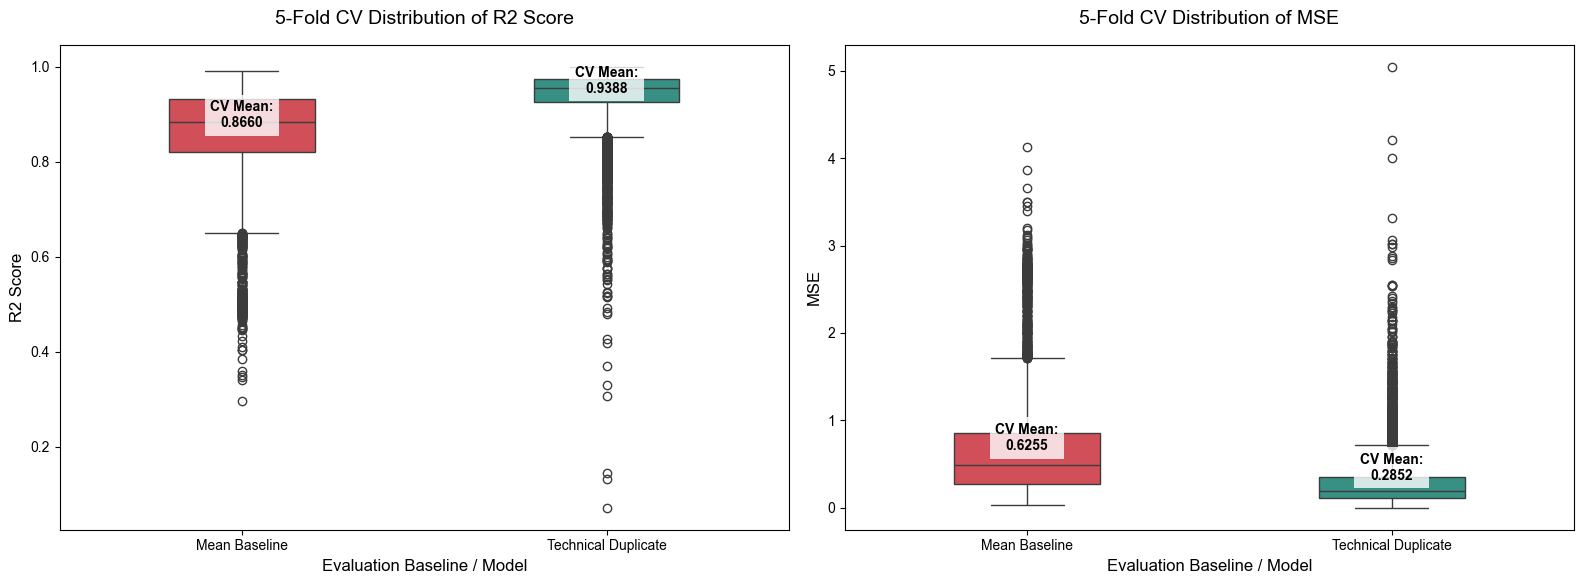

In [75]:
# 1. Initialize a single master list to hold all fold results
cv_results = []

for i in range(5):
    # Set the exact column name used for this fold's split
    split_col = f"canonical_smiles_split_{i}"
    
    # 2. Correctly isolate Train and Test subsets for this fold
    adata_train = adata[adata.obs[split_col] == "train"].copy()
    adata_test  = adata[adata.obs[split_col] == "test"].copy()
    
    # 3. Extract the clean unique list of test compounds for this fold
    test_compounds_list = list(adata_test.obs["pert_id"].unique())
    
    # 4. Compute the Mean Baseline matrix using ONLY TRAINING data
    # (Using the function name we wrote earlier to avoid name-shadowing)
    baseline_matrix_fold = mean_baseline(
        adata_train=adata_train
    )
    
    # 5. Compute technical duplicate and ground truth profiles on the test split
    technical_duplicate, ground_truth = compute_technical_duplicate(
        adata, 
        split_col,  # Fixed the missing underscore typo here
        mode="test"
    )
    
    # 6. Save everything neatly structured into a dictionary for this fold
    cv_results.append({
        "fold_index": i,
        "baseline_df": baseline_matrix_fold,
        "adata_test": adata_test,
        "gt_profiles": ground_truth,
        "td_profiles": technical_duplicate,
        "model_td_profiles": None  # When your ML model is ready, put its prediction dict here!
    })

# --- 7. Call the visualization function ---
plot_performance(cv_results)

In [6]:
split_batch_00_path = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/intermediates/preprocessed_dataset.h5ad")

split_batch_00 = sc.read_h5ad(split_batch_00_path)

In [7]:
split_batch_00_cp = split_batch_00[split_batch_00.obs["control"] == 0]

In [8]:
def print_split_percentages(adata, split_settings):
    """
    Prints the absolute count and percentage breakdown of train/valid/test 
    assignments for each split key and fold.
    """
    total_compounds = adata.n_obs
    for split_key in split_settings:
        print(f"\n--- Split Key: '{split_key}' ---")
        
        # Find all split column names created for this split key
        split_cols = [c for c in adata.obs.columns if c.startswith(f"{split_key}_split_")]
        
        for col in sorted(split_cols):
            # Focus only on the compound subset

            counts = adata.obs[col].value_counts()

            n_train = counts.get("train", 0)
            n_val   = counts.get("valid", 0)
            n_test  = counts.get("test", 0)

            pct_train = (n_train / total_compounds) * 100
            pct_val   = (n_val / total_compounds) * 100
            pct_test  = (n_test / total_compounds) * 100

            print(
                f"[{col}] "
                f"Train: {pct_train:5.1f}% ({n_train:4d}) | "
                f"Val: {pct_val:5.1f}% ({n_val:4d}) | "
                f"Test: {pct_test:5.1f}% ({n_test:4d})"
            )

# Execute the safety check on your AnnData object:
print_split_percentages(
    adata=split_batch_00_cp, 
    split_settings=["canonical_smiles", "fingerprint_smiles"], 
)


--- Split Key: 'canonical_smiles' ---
[canonical_smiles_split_0] Train:  60.1% (437764) | Val:  19.9% (145071) | Test:  20.0% (145320)
[canonical_smiles_split_1] Train:  60.1% (437318) | Val:  20.0% (145516) | Test:  20.0% (145321)
[canonical_smiles_split_2] Train:  60.0% (437130) | Val:  20.0% (145706) | Test:  20.0% (145319)
[canonical_smiles_split_3] Train:  60.0% (437151) | Val:  19.9% (144973) | Test:  20.1% (146031)
[canonical_smiles_split_4] Train:  60.0% (436667) | Val:  20.0% (145324) | Test:  20.1% (146164)

--- Split Key: 'fingerprint_smiles' ---
[fingerprint_smiles_split_0] Train:  60.2% (438325) | Val:  20.0% (145333) | Test:  19.8% (144497)
[fingerprint_smiles_split_1] Train:  60.1% (437590) | Val:  20.0% (145348) | Test:  19.9% (145217)
[fingerprint_smiles_split_2] Train:  60.1% (437730) | Val:  19.9% (145213) | Test:  19.9% (145212)
[fingerprint_smiles_split_3] Train:  60.0% (437205) | Val:  19.8% (144338) | Test:  20.1% (146612)
[fingerprint_smiles_split_4] Train:  60